# Update datasets
Notebook `src/benchmark/generate_voxel_scene_datasets.ipynb` generated the datasets with only the voxel scenes. Now create the **multiple choice** and **5 views** tasks. 

In [ ]:
import sys
from pathlib import Path
import json
import copy

# Add src to path for imports
sys.path.insert(0, str(Path.cwd().parent.parent.parent / "src"))

import numpy as np
from generation.projection import get_orthographic_views
from generation.visualization import show_isometric_view, show_orthographic_views

## Open a dataset to test

In [4]:
def open_dataset(path: Path) -> dict:
    with open(path, "r") as f:
        dataset = json.load(f)
        print(f"Loaded dataset with {len(dataset['tasks'])} tasks from {path}")
    return dataset

input_path = Path.cwd().parent.parent.parent / "datasets" / "raw" / f"orthographic_dataset_fixed_3_tasks.json" 
dataset = open_dataset(input_path)

Loaded dataset with 200 tasks from /Users/joost/vscode/ai-measuring-toward-agi-competition/datasets/raw/orthographic_dataset_fixed_3_tasks.json


In [5]:
dataset['tasks'][0]

{'id': '42_001',
 'voxels': [[[0, 0, 0], [0, 0, 0], [0, 0, 5]],
  [[0, 0, 0], [9, 0, 0], [0, 0, 0]],
  [[9, 0, 0], [0, 0, 8], [0, 0, 0]]]}

## Front and top views are given, select the right view from 4 multiple choices
Add/update the dataset:
- Derive from the scene voxel the front, top and right ortho views
- The right view is anser. Add 4 multiple choices with the right answer randomized

In [6]:
mc_randomized = [1,2,3,4]
np.random.shuffle(mc_randomized)
answer = mc_randomized.index(4) + 1
print(mc_randomized, answer)

[1, 3, 4, 2] 3


In [7]:
def update_dataset_with_multiple_choices(dataset):
    """
    Update a dataset with orthographic view tasks.
    
    Args:
        dataset: Existing dataset to update
        with_multiple_choices: Whether to include multiple choice options
        
    Returns:
        List of dicts, each containing:
        - 'id': Task identifier
        - 'voxels': Voxel representation of the scene
        - 'input': Dict with 'front' and 'top' views (as lists)
        - 'multiple_choices': Dict with 4 remaining views (as lists), one of which is the right view (correct answer)
        - 'answer': correct entry number (1-4)
    """
    dataset = copy.deepcopy(dataset)

    for task in dataset["tasks"]:
        voxel_scene = np.array(task["voxels"])
        ortho_views = get_orthographic_views(voxel_scene)
        
        task["input"] = {
            "front": ortho_views["front"].tolist(),
            "top": ortho_views["top"].tolist(),
        }

        # Create multiple choice options by shuffling the correct answer with 3 incorrect views
        mc_randomized = [1,2,3,4]
        np.random.shuffle(mc_randomized)
        choices = [ortho_views["back"].tolist(), ortho_views["bottom"].tolist(), ortho_views["left"].tolist(), ortho_views["right"].tolist()]
        randomized_choices = [choices[i-1] for i in mc_randomized]

        task["multiple_choices"] = {
            "1": randomized_choices[0],
            "2": randomized_choices[1],
            "3": randomized_choices[2],
            "4": randomized_choices[3],
        }
        task["answer"] = mc_randomized.index(4) + 1

    return dataset

In [8]:
dataset_mc = update_dataset_with_multiple_choices(dataset)

In [9]:
dataset_mc["tasks"][0]

{'id': '42_001',
 'voxels': [[[0, 0, 0], [0, 0, 0], [0, 0, 5]],
  [[0, 0, 0], [9, 0, 0], [0, 0, 0]],
  [[9, 0, 0], [0, 0, 8], [0, 0, 0]]],
 'input': {'front': [[5, 0, 8], [0, 0, 0], [0, 9, 9]],
  'top': [[5, 0, 0], [0, 9, 8], [0, 0, 9]]},
 'multiple_choices': {'1': [[5, 8, 0], [0, 0, 0], [0, 9, 9]],
  '2': [[8, 0, 5], [0, 0, 0], [9, 9, 0]],
  '3': [[0, 8, 5], [0, 0, 0], [9, 9, 0]],
  '4': [[0, 0, 9], [0, 9, 8], [5, 0, 0]]},
 'answer': 3}

## Predict the right view using the 5 other views

In [10]:
def update_dataset_with_orthographics(dataset):
    """
    Update a dataset with orthographic view tasks.
    
    Args:
        dataset: Existing dataset to update
        
    Returns:
        List of dicts, each containing:
        - 'id': Task identifier
        - 'voxels': Voxel representation of the scene
        - 'input': Dict with 'front' and 'top' views (as lists)
    """

    dataset = copy.deepcopy(dataset)

    for task in dataset["tasks"]:
        voxel_scene = np.array(task["voxels"])
        ortho_views = get_orthographic_views(voxel_scene)
        
        task["input"] = {
            "front": ortho_views["front"].tolist(),
            "top": ortho_views["top"].tolist(),
            "back": ortho_views["back"].tolist(),
            "bottom": ortho_views["bottom"].tolist(),
            "left": ortho_views["left"].tolist()
        }

        task["answer"] = ortho_views["right"].tolist()
        
    return dataset

In [11]:
dataset_5v = update_dataset_with_orthographics(dataset)

## Quick viewer

In [12]:
# The answers are different between the two datasets, so we need to check the types
type(dataset_5v['tasks'][0]['answer']), type(dataset_mc['tasks'][0]['answer'])

(list, int)

In [13]:
def visualize_tasks(selection):
    for task in selection:
        show_isometric_view(np.array(task['voxels']))
        if type(task['answer']) == int:
            print(f"Multiple choice task:")
            ortho_views = {
                'front': np.array(task['input']['front']),
                'top': np.array(task['input']['top']),
                'right': np.array(task['multiple_choices'][str(task['answer'])])  # Get the correct choice
            }
        else:
            print(f"Predict right view task:")
            ortho_views = {
                'front': np.array(task['input']['front']),
                'top': np.array(task['input']['top']),
                'left': np.array(task['input']['left']),
                'back': np.array(task['input']['back']),
                'bottom': np.array(task['input']['bottom']),
                'right': np.array(task['answer'])  
            }
            
        show_orthographic_views(ortho_views)

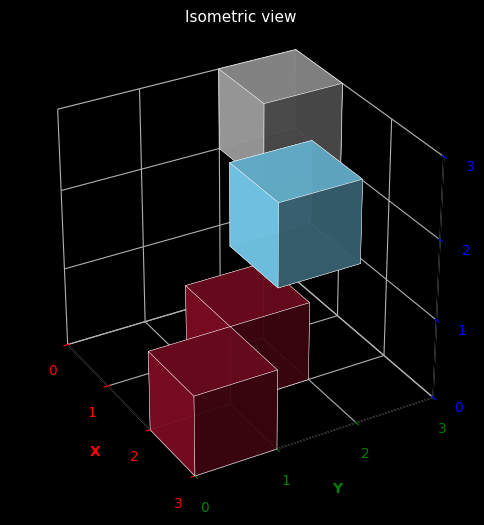

Multiple choice task:


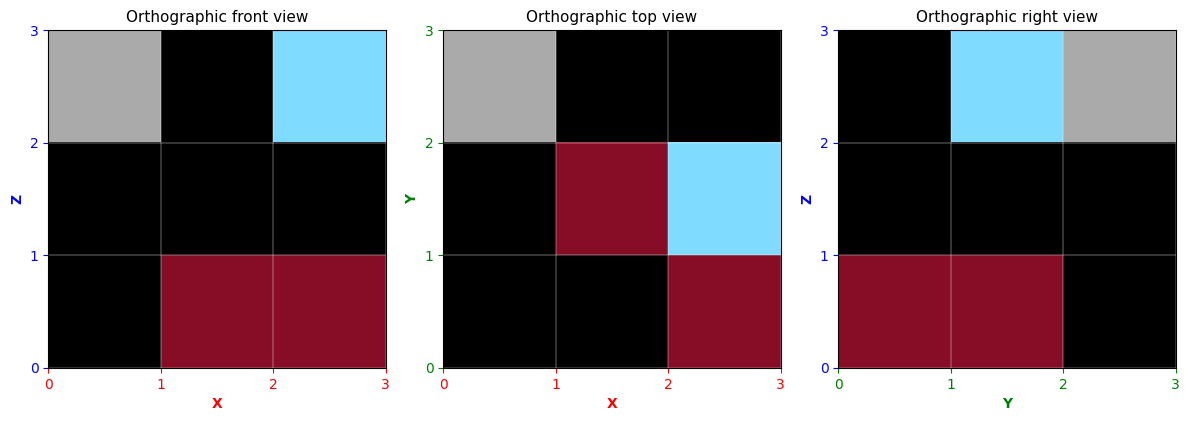

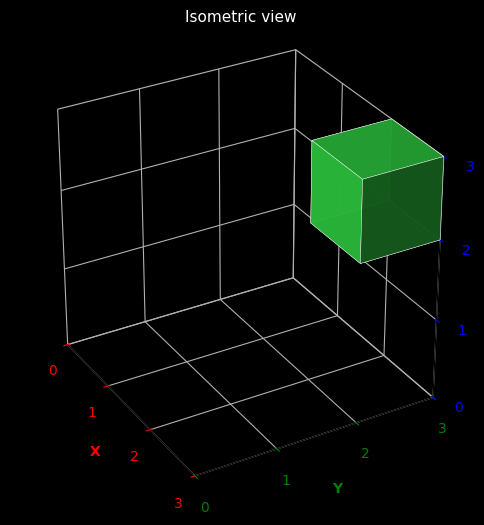

Multiple choice task:


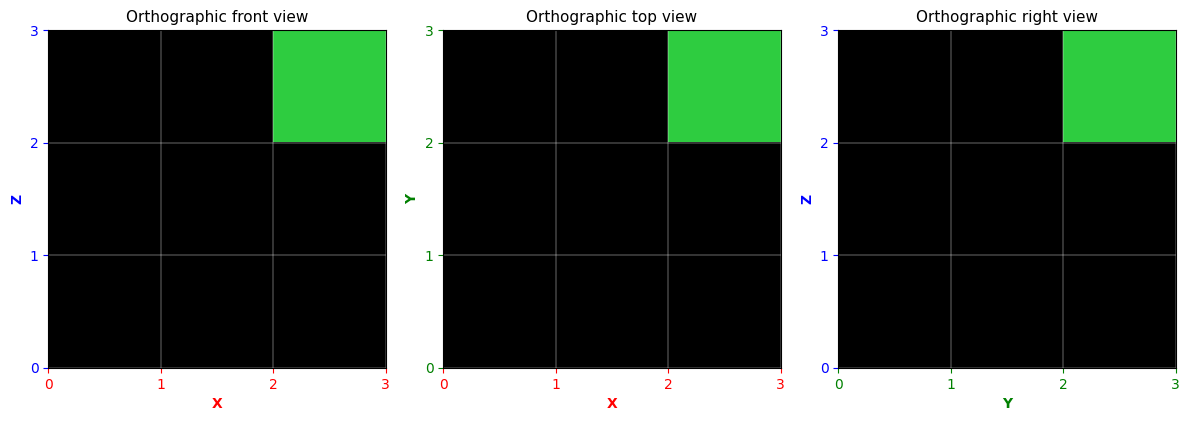

In [14]:
visualize_tasks(dataset_mc['tasks'][:2])

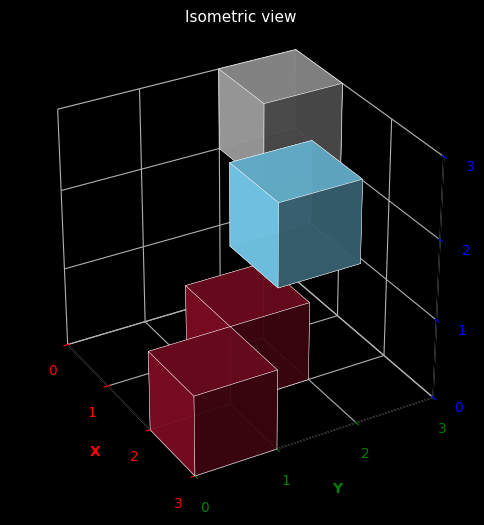

Predict right view task:


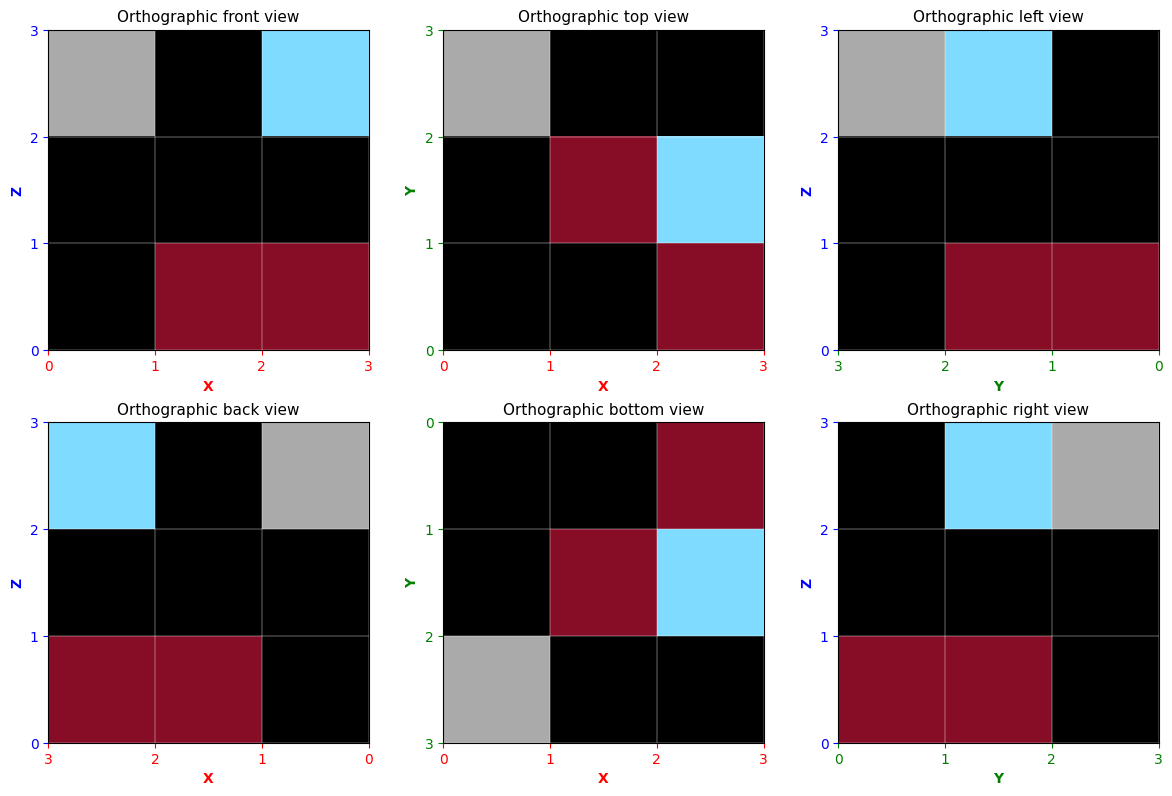

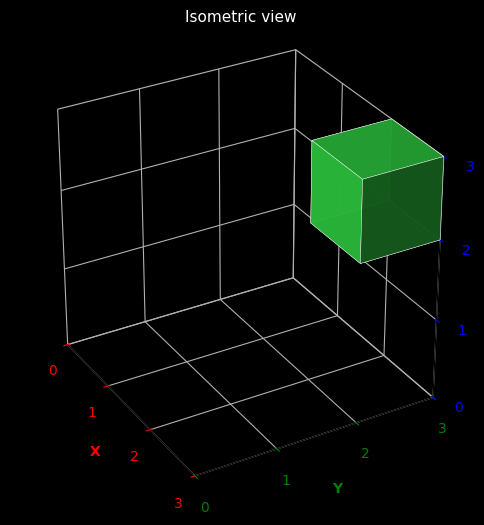

Predict right view task:


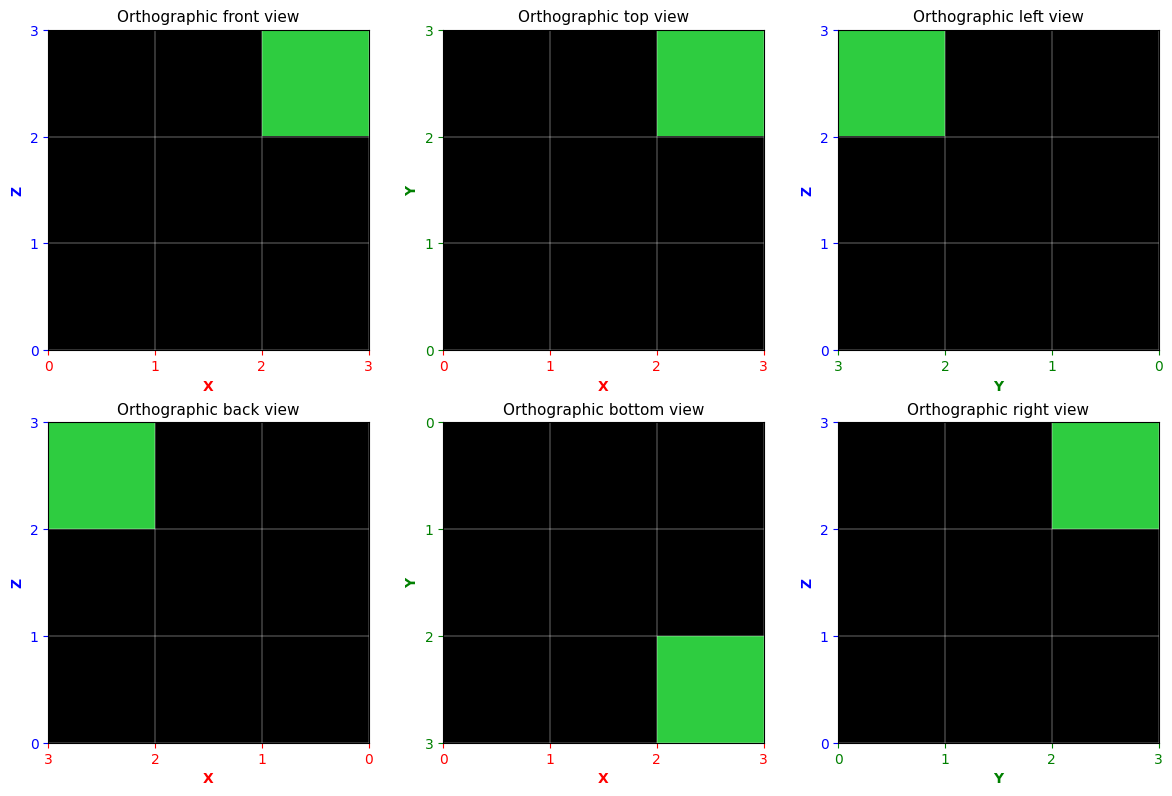

In [15]:
visualize_tasks(dataset_5v['tasks'][:2])

## Generate benchmark datasets using the raw folder

In [16]:
input_path = Path.cwd().parent.parent.parent / "datasets" / "raw" 

input_files = {
    path.stem: path
    for path in input_path.glob("*.json")
    if path.stem.startswith("orthographic_dataset_")
}

print(f"Found {len(input_files)} files in {input_path}")
input_files

Found 3 files in /Users/joost/vscode/ai-measuring-toward-agi-competition/datasets/raw


{'orthographic_dataset_fixed_3_tasks': PosixPath('/Users/joost/vscode/ai-measuring-toward-agi-competition/datasets/raw/orthographic_dataset_fixed_3_tasks.json'),
 'orthographic_dataset_fixed_4_tasks': PosixPath('/Users/joost/vscode/ai-measuring-toward-agi-competition/datasets/raw/orthographic_dataset_fixed_4_tasks.json'),
 'orthographic_dataset_fixed_5_tasks': PosixPath('/Users/joost/vscode/ai-measuring-toward-agi-competition/datasets/raw/orthographic_dataset_fixed_5_tasks.json')}

In [ ]:
output_path = Path.cwd().parent.parent.parent / "datasets" / "kaggle_benchmark"
output_path.mkdir(parents=True, exist_ok=True)

for filename_stem, filepath in input_files.items():
    print(f"\nProcessing {filename_stem}...")
    ds = open_dataset(filepath)
    
    # Generate multiple choice dataset
    ds_mc = update_dataset_with_multiple_choices(ds)
    mc_filename = filename_stem.replace("orthographic_dataset_", "orthographic_dataset_mc_") + ".json"
    mc_output = output_path / mc_filename
    with open(mc_output, "w") as f:
        json.dump(ds_mc, f, indent=2)
    print(f"  Saved MC dataset to {mc_output}")
    
    # Generate 5-view dataset
    ds_5v = update_dataset_with_orthographics(ds)
    fv_filename = filename_stem.replace("orthographic_dataset_", "orthographic_dataset_5v_") + ".json"
    fv_output = output_path / fv_filename
    with open(fv_output, "w") as f:
        json.dump(ds_5v, f, indent=2)
    print(f"  Saved 5V dataset to {fv_output}")

print(f"\n✅ All datasets processed and saved to {output_path}")


Processing orthographic_dataset_fixed_3_tasks...
Loaded dataset with 200 tasks from /Users/joost/vscode/ai-measuring-toward-agi-competition/datasets/raw/orthographic_dataset_fixed_3_tasks.json
  Saved MC dataset to /Users/joost/vscode/ai-measuring-toward-agi-competition/datasets/kaggle_benchmark/orthographic_dataset_mc_fixed_3_tasks_1.json
  Saved 5V dataset to /Users/joost/vscode/ai-measuring-toward-agi-competition/datasets/kaggle_benchmark/orthographic_dataset_5v_fixed_3_tasks_1.json

Processing orthographic_dataset_fixed_4_tasks...
Loaded dataset with 200 tasks from /Users/joost/vscode/ai-measuring-toward-agi-competition/datasets/raw/orthographic_dataset_fixed_4_tasks.json
  Saved MC dataset to /Users/joost/vscode/ai-measuring-toward-agi-competition/datasets/kaggle_benchmark/orthographic_dataset_mc_fixed_4_tasks_1.json
  Saved 5V dataset to /Users/joost/vscode/ai-measuring-toward-agi-competition/datasets/kaggle_benchmark/orthographic_dataset_5v_fixed_4_tasks_1.json

Processing orth

## Create Kaggle dataset

Add the files from `datasets/kaggle_benchmark` to Kaggle dataset.